# Exploración inicial del dataset Financial PhraseBank

### Objetivo del notebook
Este notebook tiene como objetivo realizar una primera exploración del dataset **Financial PhraseBank**, que será utilizado para entrenar modelos de clasificación de sentimiento en noticias financieras.
Este análisis servirá como base para diseñar el pipeline de preprocesamiento, validación de datos y modelado.


---


### 1. Objetivo de esta fase exploratoria

Antes de entrenar modelos, necesitamos responder preguntas básicas sobre los datos:

1. ¿Cuántas filas y columnas tiene el dataset?
2. ¿Cómo se llaman las columnas?
3. ¿Qué tipo de datos contiene cada columna?
4. ¿Existen valores faltantes?
5. ¿Existen textos duplicados?
6. ¿Cuántos ejemplos hay por cada clase?
7. ¿El dataset está balanceado o desbalanceado?
8. ¿Qué longitud tienen los textos?
9. ¿Qué ejemplos aparecen en cada clase?
10. ¿Qué problemas potenciales debemos resolver antes del modelado?


---


#### Carga del dataset

En esta sección se cargará el archivo CSV descargado previamente.
La carga inicial se realiza desde la carpeta `data/raw/`, ya que todavía estamos trabajando con los datos originales.
En esta etapa no se aplicará ninguna transformación permanente al dataset.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [5]:
PATH = Path("../data/raw/financial_phrasebank.csv")
df = pd.read_csv(PATH, encoding="utf-8")

#### Primeras impresiones

In [20]:
print(df.sample(3))
print(df.sample(3, random_state=42))
print("---\n")
print(f"Shape:\t{df.shape}")
print(f"\nColumns: {df.columns}")
print(f"\nValores nulos: \n{df.isna().sum()}")
print(f"\nDuplicados exactos: {df.duplicated().sum()}")
print(f"\nTextos duplicados: {df['sentence'].duplicated().sum()}")

                                               sentence  label
2914  Fortum had intended to spend as much as ( EURO...      1
175   Both operating profit and turnover for the six...      2
1649  The potential acquirer is Cencorp Corporation ...      1
                                               sentence  label
3207  The company was supposed to deliver machinery ...      1
1684  UNC Charlotte would also deploy SSH Tectia Con...      1
1044  In 2009 , Lee & Man had a combined annual prod...      1
---

Shape:	(4846, 2)

Columns: Index(['sentence', 'label'], dtype='str')

Valores nulos: 
sentence    0
label       0
dtype: int64

Duplicados exactos: 6

Textos duplicados: 8


#### Información

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4846 entries, 0 to 4845
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   sentence  4846 non-null   str  
 1   label     4846 non-null   int64
dtypes: int64(1), str(1)
memory usage: 682.4 KB


#### Revision de los valores duplicados

In [23]:
duplicated_texts = df[df["sentence"].duplicated(keep=False)].sort_values("sentence")

duplicated_texts.head(20)


,sentence,label
2395,Ahlstrom 's share is quoted on the NASDAQ OMX ...,1
2396,Ahlstrom 's share is quoted on the NASDAQ OMX ...,1
3093,Proha Plc ( Euronext :7327 ) announced today (...,1
3094,Proha Plc ( Euronext :7327 ) announced today (...,1
2566,SSH Communications Security Corporation is hea...,1
2567,SSH Communications Security Corporation is hea...,1
78,TELECOMWORLDWIRE-7 April 2006-TJ Group Plc sel...,1
79,TELECOMWORLDWIRE-7 April 2006-TJ Group Plc sel...,2
788,The Group 's business is balanced by its broad...,2
789,The Group 's business is balanced by its broad...,1


#### Mapeo de etiquetas

In [24]:
label_mapping = {
    0: "negative",
    1: "neutral",
    2: "positive",
}

df["label_name"] = df["label"].map(label_mapping)

df.head()

,sentence,label,label_name
0,"According to Gran , the company has no plans t...",1,neutral
1,Technopolis plans to develop in stages an area...,1,neutral
2,The international electronic industry company ...,0,negative
3,With the new production plant the company woul...,2,positive
4,According to the company 's updated strategy f...,2,positive


#### Distribucion de clases

In [25]:
class_counts = df["label_name"].value_counts()
class_percentages = df["label_name"].value_counts(normalize=True).mul(100).round(2)

print("Conteo por clase:")
print(class_counts)

print("\nPorcentaje por clase:")
print(class_percentages)

Conteo por clase:
label_name
neutral     2879
positive    1363
negative     604
Name: count, dtype: int64

Porcentaje por clase:
label_name
neutral     59.41
positive    28.13
negative    12.46
Name: proportion, dtype: float64


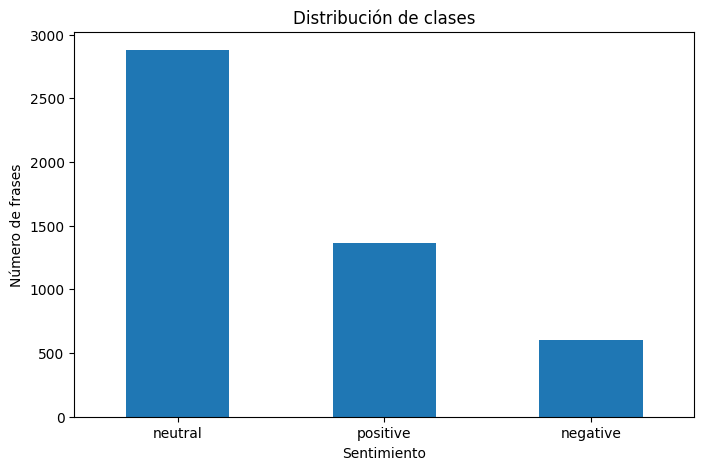

In [26]:
plt.figure(figsize=(8, 5))
class_counts.plot(kind="bar")
plt.title("Distribución de clases")
plt.xlabel("Sentimiento")
plt.ylabel("Número de frases")
plt.xticks(rotation=0)
plt.show()


#### Longitud de textos


In [28]:
df["text_length_chars"] = df["sentence"].str.len()
df["text_length_words"] = df["sentence"].str.split().str.len()

print(df[["text_length_chars", "text_length_words"]].describe())

df.head()

       text_length_chars  text_length_words
count        4846.000000        4846.000000
mean          128.132068          23.101114
std            56.526180           9.958474
min             9.000000           2.000000
25%            84.000000          16.000000
50%           119.000000          21.000000
75%           163.000000          29.000000
max           315.000000          81.000000


,sentence,label,label_name,text_length_chars,text_length_words
0,"According to Gran , the company has no plans t...",1,neutral,127,25
1,Technopolis plans to develop in stages an area...,1,neutral,190,31
2,The international electronic industry company ...,0,negative,228,36
3,With the new production plant the company woul...,2,positive,206,33
4,According to the company 's updated strategy f...,2,positive,203,41


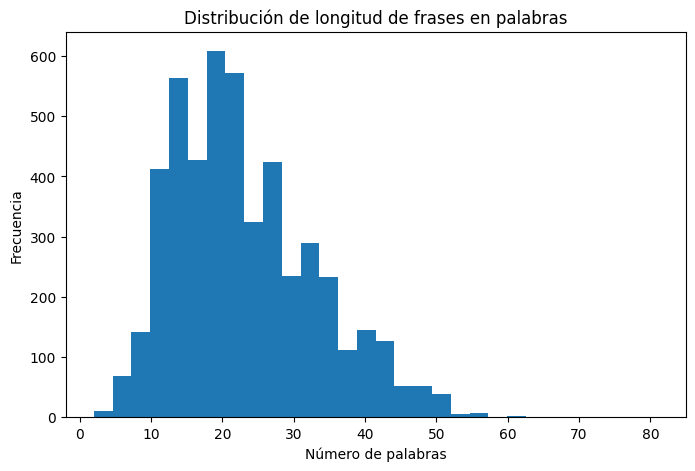

In [29]:
plt.figure(figsize=(8, 5))
df["text_length_words"].plot(kind="hist", bins=30)
plt.title("Distribución de longitud de frases en palabras")
plt.xlabel("Número de palabras")
plt.ylabel("Frecuencia")
plt.show()

#### Longitud por clase

In [30]:
df.groupby("label_name")[["text_length_chars", "text_length_words"]].describe()

text_length_chars                                                   \
                       count        mean        std   min   25%    50%    75%   
label_name                                                                      
negative               604.0  125.756623  52.903636  37.0  85.0  118.0  157.0   
neutral               2879.0  125.072247  57.069526   9.0  81.0  116.0  161.0   
positive              1363.0  135.647836  56.268661  24.0  91.5  128.0  175.0   

                  text_length_words                                         \
              max             count       mean        std  min   25%   50%   
label_name                                                                   
negative    296.0             604.0  23.917219   9.887414  5.0  17.0  22.0   
neutral     315.0            2879.0  22.176450   9.815893  2.0  15.0  21.0   
positive    298.0            1363.0  24.692590  10.062878  5.0  17.0  23.0   

                        
             75%   max  
label_name              
negative    30.0  56.0  
neutral     28.0  81.0  
positive    31.0  57.0

<Figure size 800x500 with 0 Axes>

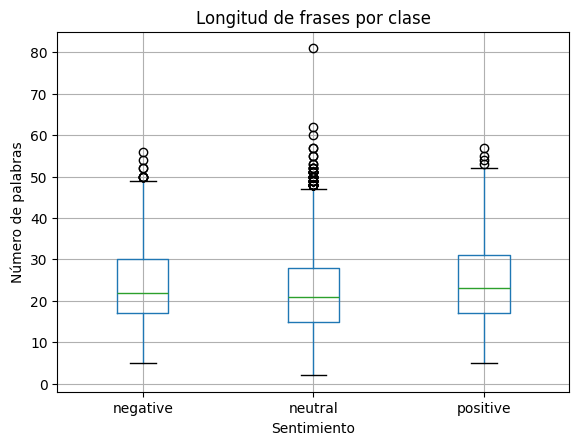

In [31]:
plt.figure(figsize=(8, 5))
df.boxplot(column="text_length_words", by="label_name")
plt.title("Longitud de frases por clase")
plt.suptitle("")
plt.xlabel("Sentimiento")
plt.ylabel("Número de palabras")
plt.show()


### Ejemplos de textos 

In [33]:
for label_name in df["label_name"].dropna().unique():
    print("=" * 80)
    print(f"Clase: {label_name}")
    print("=" * 80)
    
    examples = df[df["label_name"] == label_name]["sentence"].sample(5, random_state=42)
    
    for text in examples:
        print(f"- {text}")
    
    print()

Clase: neutral
- The center offers a comprehensive range of device design services spanning from electronics , mechanics and software design to a full range of testing laboratory services .
- AffectoGenimap builds highly customised IT solutions for its customers in Finland and the Baltic countries .
- The bank 's leasing arm Nordea Liising ended the year with a profit of 4.4 million euros .
- Her present position is the director of Stockmann 's international department stores .
- Ahlstrom 's 5,800 employees serve customers via sales offices and production facilities in more than 20 countries on six continents .

Clase: negative
- The company decided at the end of 2008 to temporarily shut down its ammonia plant in Billingham and extend the maintenance period at its Ince facility .
- down to EUR5 .9 m H1 '09 3 August 2009 - Finnish media group Ilkka-Yhtyma Oyj ( HEL : ILK2S ) said today its net profit fell 45 % on the year to EUR5 .9 m in the first half of 2009 .
- The steelmaker said th